In [39]:
# here we are completely implemeting a Short-Term Memory.. 

# where we are summarizing the past messages and deleting them from memory..
# so we have summary of past messages and trimmed recent messages..

In [40]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_core.messages import HumanMessage, RemoveMessage, SystemMessage
from psycopg_pool import ConnectionPool
from dotenv import load_dotenv
import os

In [41]:
load_dotenv()

True

In [42]:
LLM = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [43]:
DB_URI = os.environ["DATABASE_URL"]

connection_kwargs = {
    "autocommit":True,
    "prepare_threshold":0
}

In [44]:
pool = ConnectionPool(
    conninfo=DB_URI,
    max_size=20,
    kwargs=connection_kwargs
)

checkpointer = PostgresSaver(pool)
checkpointer.setup()

In [45]:
class ChatState(MessagesState):
    summary: str

In [46]:
def summarize_conversation(state:ChatState):
    existing_summary = state.get("summary","")

    if existing_summary:
        prompt = f"""
Existing Summary: {existing_summary}

Extend the summary using new conversation above
"""
    else:
        prompt = "Summarize the conversation above"

    message_for_summary = state["messages"] + [HumanMessage(content=prompt)]
    response = LLM.invoke(message_for_summary)

    # keep only last 2 messages..
    messages_to_delete = state["messages"][:-2]

    return {
        "summary":response.content,
        "messages":[RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [47]:
def chat_node(state:ChatState):
    messages = []

    summary = state.get("summary","")
    if summary:
        messages.append(
            SystemMessage(
                content= f"""
Previous conversation summary:

{state["summary"]}

use this summary as a context when answering..
"""
            )
        )

    messages.extend(state["messages"])
    print(messages)

    response = LLM.invoke(messages)
    return {"messages":[response]}

In [48]:
# if we have more than 6 messages then we summarize first 6 and keep latest messages..

def should_summarize(state:ChatState):
    return len(state["messages"]) > 6

In [49]:
graph_builder = StateGraph(ChatState)

graph_builder.add_node("chat_node",chat_node)
graph_builder.add_node("summarize_conversation",summarize_conversation)

graph_builder.add_edge(START,"chat_node")
graph_builder.add_conditional_edges("chat_node",should_summarize,{True:"summarize_conversation",False:END})
graph_builder.add_edge("summarize_conversation",END)

graph = graph_builder.compile(checkpointer=checkpointer)

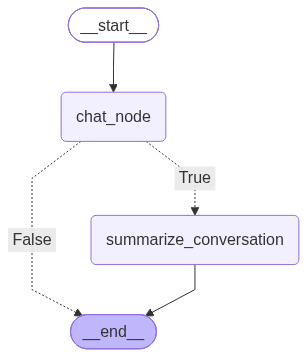

In [50]:
graph

In [51]:
CONFIG = {"configurable":{"thread_id":"102"}}

def run(text:str):
    out = graph.invoke({"messages":[HumanMessage(content=text)]},config=CONFIG)
    return out

In [52]:
# gives current version of state
def show_state():
    snap = graph.get_state(CONFIG)
    vals = snap.values
    print("\n-------- STATE ---------")
    print("Summary: ",vals.get("summary",""))
    print("Total Number of Messages: ",len(vals.get("messages",[])))
    print("Messages:")
    for m in vals.get("messages",[]):
        print("-",type(m).__name__,": ",m.content[:80])

In [53]:
run("Hi i am jane")
show_state()

[HumanMessage(content='ok tell me something about chatgpt', additional_kwargs={}, response_metadata={}, id='e893a6e3-1cbc-4f0e-82d5-aaa8ddd035eb'), AIMessage(content="ChatGPT is a fascinating topic. Here's an overview:\n\n**What is ChatGPT?**\nChatGPT is an AI chatbot developed by OpenAI, the same organization I told you about earlier. ChatGPT is a conversational AI model that uses natural language processing (NLP) to understand and respond to human input.\n\n**How does ChatGPT work?**\nChatGPT is based on a type of recurrent neural network (RNN) called a transformer. This architecture allows the model to process and generate human-like text based on the input it receives. ChatGPT has been trained on a massive dataset of text from various sources, including books, articles, and conversations.\n\n**Key features:**\n\n1. **Conversational interface:** ChatGPT allows users to interact with it in a conversational manner, using natural language to ask questions, provide input, or engage in d

In [54]:
run("tell me something about OpenAI")
show_state()

[HumanMessage(content='ok tell me something about chatgpt', additional_kwargs={}, response_metadata={}, id='e893a6e3-1cbc-4f0e-82d5-aaa8ddd035eb'), AIMessage(content="ChatGPT is a fascinating topic. Here's an overview:\n\n**What is ChatGPT?**\nChatGPT is an AI chatbot developed by OpenAI, the same organization I told you about earlier. ChatGPT is a conversational AI model that uses natural language processing (NLP) to understand and respond to human input.\n\n**How does ChatGPT work?**\nChatGPT is based on a type of recurrent neural network (RNN) called a transformer. This architecture allows the model to process and generate human-like text based on the input it receives. ChatGPT has been trained on a massive dataset of text from various sources, including books, articles, and conversations.\n\n**Key features:**\n\n1. **Conversational interface:** ChatGPT allows users to interact with it in a conversational manner, using natural language to ask questions, provide input, or engage in d

In [55]:
run("ok what is my name?")
show_state()

[SystemMessage(content="\nPrevious conversation summary:\n\nHere's a summary of our conversation:\n\n* We discussed ChatGPT, a conversational AI model developed by OpenAI, and its capabilities, features, and limitations.\n* You introduced yourself as Jane, and we had a brief chat about your day.\n* We then talked about OpenAI, a non-profit AI research organization, and its mission to develop and promote AI in a way that benefits humanity.\n* I provided an overview of OpenAI's key projects, values, and impact on the AI research community and the world at large.\n\nLet me know if you'd like to continue the conversation or if you have any other questions!\n\nuse this summary as a context when answering..\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='tell me something about OpenAI', additional_kwargs={}, response_metadata={}, id='82165834-5153-4659-9c85-ef7bd583e4d0'), AIMessage(content="OpenAI is a fascinating organization. Here's an overview:\n\n**What is OpenAI?

In [56]:
run("ok tell me something about chatgpt")
show_state()

[SystemMessage(content="\nPrevious conversation summary:\n\nHere's a summary of our conversation:\n\n* We discussed ChatGPT, a conversational AI model developed by OpenAI, and its capabilities, features, and limitations.\n* You introduced yourself as Jane, and we had a brief chat about your day.\n* We then talked about OpenAI, a non-profit AI research organization, and its mission to develop and promote AI in a way that benefits humanity.\n* I provided an overview of OpenAI's key projects, values, and impact on the AI research community and the world at large.\n\nLet me know if you'd like to continue the conversation or if you have any other questions!\n\nuse this summary as a context when answering..\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='tell me something about OpenAI', additional_kwargs={}, response_metadata={}, id='82165834-5153-4659-9c85-ef7bd583e4d0'), AIMessage(content="OpenAI is a fascinating organization. Here's an overview:\n\n**What is OpenAI?

In [57]:
run("what was my name??")
show_state()

[SystemMessage(content="\nPrevious conversation summary:\n\nHere's a summary of our conversation:\n\n* We discussed ChatGPT, a conversational AI model developed by OpenAI, and its capabilities, features, and limitations.\n* You introduced yourself as Jane, and we had a brief chat about your day.\n* We then talked about OpenAI, a non-profit AI research organization, and its mission to develop and promote AI in a way that benefits humanity.\n* I provided an overview of OpenAI's key projects, values, and impact on the AI research community and the world at large.\n\nLet me know if you'd like to continue the conversation or if you have any other questions!\n\nuse this summary as a context when answering..\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='tell me something about OpenAI', additional_kwargs={}, response_metadata={}, id='82165834-5153-4659-9c85-ef7bd583e4d0'), AIMessage(content="OpenAI is a fascinating organization. Here's an overview:\n\n**What is OpenAI?